Climate Change in Africa 
In this checkpoint, we are going to work on the 'Climate change in Africa' dataset that was provided by the U.S global change research program.

Dataset description : This dataset contains historical data about the daily min, max and average temperature fluctuation in 5 African countries (Egypt, Tunisia, Cameroon, Senegal, Angola) between 1980 and 2023.

➡️ Dataset link

https://i.imgur.com/w2czdso.jpg

Load the dataset into a data frame using Python.
Clean the data as needed.
Plot a line chart to show the average temperature fluctuations in Tunisia and Cameroon. Interpret the results.
Zoom in to only include data between 1980 and 2005, try to customize the axes labels.
Create Histograms to show temperature distribution in Senegal between [1980,2000] and [2000,2023] (in the same figure). Describe the obtained results.
Select the best chart to show the Average temperature per country.
Make your own questions about the dataset and try to answer them using the appropriate visuals.
 
Note: Feel free to choose the visualization library (e.g., Matplotlib, Seaborn, Plotly) that best suits your style and the requirements of the tasks listed below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('Africa_climate_change.csv')
#df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d %H%M%S')
df.head(10)

,DATE,PRCP,TAVG,TMAX,TMIN,COUNTRY
0,19800101 000000,NaN,54.0,61.0,43.0,Tunisia
1,19800101 000000,NaN,49.0,55.0,41.0,Tunisia
2,19800101 000000,0.0,72.0,86.0,59.0,Cameroon
3,19800101 000000,NaN,50.0,55.0,43.0,Tunisia
4,19800101 000000,NaN,75.0,91.0,NaN,Cameroon
5,19800101 000000,NaN,52.0,61.0,45.0,Tunisia
6,19800101 000000,0.0,76.0,97.0,59.0,Senegal
7,19800101 000000,0.0,74.0,95.0,59.0,Senegal
8,19800101 000000,0.0,78.0,93.0,63.0,Senegal
9,19800101 000000,0.0,76.0,91.0,59.0,Senegal


In [3]:
df = df.drop_duplicates()
df = df[df['TAVG'] > -20]          
df['DATE'] = pd.to_datetime(df['DATE'])
df['YEAR'] = df['DATE'].dt.year


daily = df.groupby(['COUNTRY', 'DATE'], as_index=False).agg(
    TAVG=('TAVG', 'mean'), TMAX=('TMAX', 'mean'), TMIN=('TMIN', 'mean'), PRCP=('PRCP', 'mean')
)
daily['YEAR'] = daily['DATE'].dt.year
daily['MONTH'] = daily['DATE'].dt.month

yearly = daily.groupby(['COUNTRY', 'YEAR'], as_index=False)['TAVG'].mean()
print('Cleaned daily rows:', len(daily))
daily.isnull().sum()

Cleaned daily rows: 68631


COUNTRY        0
DATE           0
TAVG           0
TMAX       10937
TMIN        9464
PRCP       29550
YEAR           0
MONTH          0
dtype: int64

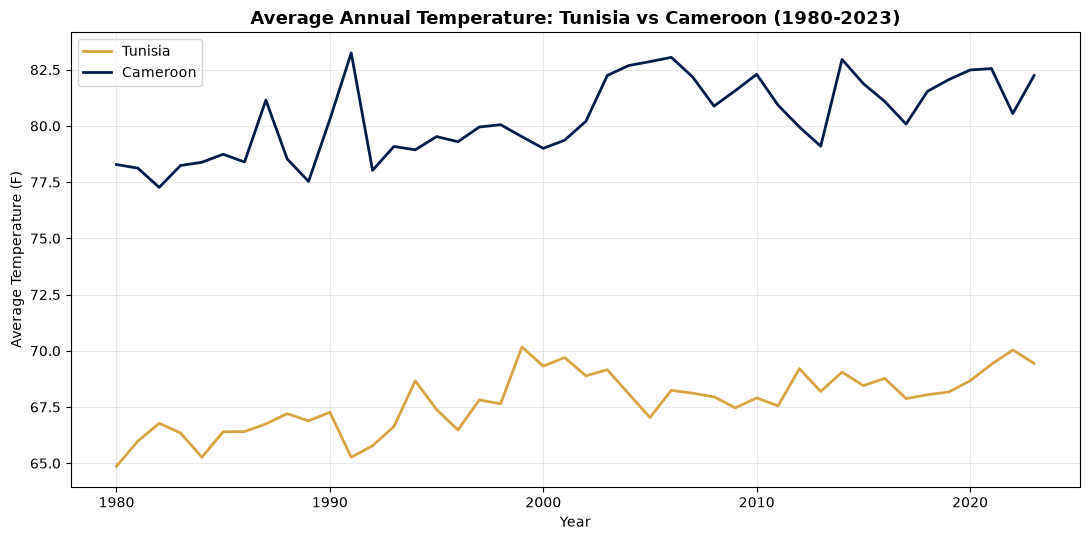

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for country, color in [('Tunisia', '#D9A441'), ('Cameroon', '#001D4A')]:
    sub = yearly[yearly['COUNTRY'] == country]
    ax.plot(sub['YEAR'], sub['TAVG'], label=country, color=color, linewidth=2)
ax.set_title('Average Annual Temperature: Tunisia vs Cameroon (1980-2023)', fontsize=13, weight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Temperature (F)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

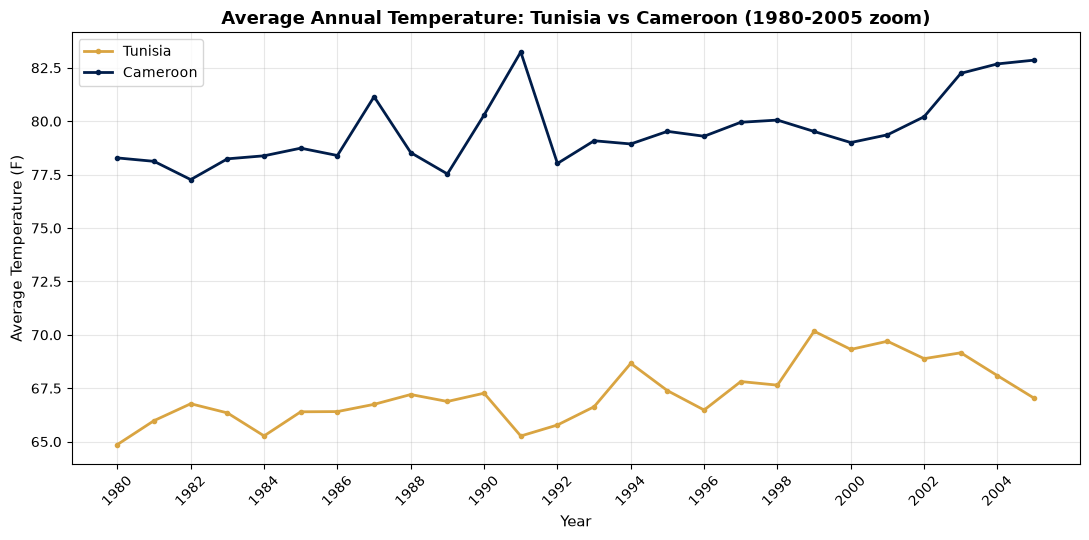

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for country, color in [('Tunisia', '#D9A441'), ('Cameroon', '#001D4A')]:
    sub = yearly[(yearly['COUNTRY'] == country) & (yearly['YEAR'].between(1980, 2005))]
    ax.plot(sub['YEAR'], sub['TAVG'], label=country, color=color, linewidth=2, marker='o', markersize=3)
ax.set_title('Average Annual Temperature: Tunisia vs Cameroon (1980-2005 zoom)', fontsize=13, weight='bold')
ax.set_xlabel('Year', fontsize=11); ax.set_ylabel('Average Temperature (F)', fontsize=11)
ax.set_xticks(range(1980, 2006, 2))
ax.set_xticklabels([str(y) for y in range(1980, 2006, 2)], rotation=45)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

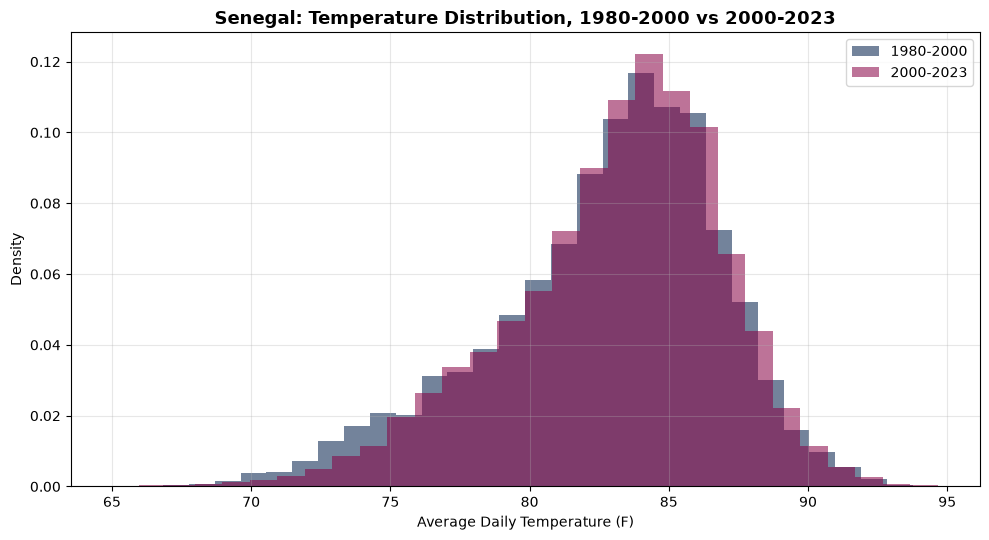

1980-2000: mean=82.70F std=4.17 (n=7661)
2000-2023: mean=83.06F std=3.90 (n=8625)


In [6]:
sen = daily[daily['COUNTRY'] == 'Senegal'].dropna(subset=['TAVG'])
sen_early = sen[sen['YEAR'].between(1980, 2000)]['TAVG']
sen_late  = sen[sen['YEAR'].between(2000, 2023)]['TAVG']

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(sen_early, bins=30, alpha=0.55, label='1980-2000', color='#001D4A', density=True)
ax.hist(sen_late,  bins=30, alpha=0.55, label='2000-2023', color='#880044', density=True)
ax.set_title('Senegal: Temperature Distribution, 1980-2000 vs 2000-2023', fontsize=13, weight='bold')
ax.set_xlabel('Average Daily Temperature (F)'); ax.set_ylabel('Density')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('1980-2000: mean=%.2fF std=%.2f (n=%d)' % (sen_early.mean(), sen_early.std(), len(sen_early)))
print('2000-2023: mean=%.2fF std=%.2f (n=%d)' % (sen_late.mean(), sen_late.std(), len(sen_late)))